# 01 Generative Vs Discriminative

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare generative and discriminative models
- Choose paradigm for generation vs classification

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook supports **Course 10, Unit 1** requirements from `DETAILED_UNIT_DESCRIPTIONS.md`.

---


# 01 Generative Vs Discriminative

## 📚 Learning Objectives | أهداف التعلم

This notebook demonstrates key concepts through hands-on examples.

By completing this notebook, you will:
- Understand the core concepts
- See practical implementations
- Be ready for exercises

## 🔗 Prerequisites | المتطلبات الأساسية

- ✅ Python 3.8+ installed
- ✅ Required libraries (see `requirements.txt`)
- ✅ Basic Python knowledge

---

## Code Example | مثال الكود

Run the code below to see the demonstration:




Visualization: Generative vs Discriminative Models


## 🌍 Real-World Worked Example — GAN Generating Handwritten Digits

**Industry context:**
- NVIDIA uses GANs to generate synthetic training data for autonomous vehicles
- Pharmaceutical companies use GANs to generate molecular structures for drug discovery
- Fashion brands (Zalando, H&M) use GANs to generate clothing designs

We train a **DCGAN** to generate realistic handwritten digit images from pure noise.

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<00:52, 188kB/s]

  1%|          | 65.5k/9.91M [00:00<00:53, 184kB/s]

  2%|▏         | 197k/9.91M [00:00<00:22, 425kB/s] 

  3%|▎         | 328k/9.91M [00:00<00:17, 561kB/s]

...

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 15.3MB/s]

Epoch 1/3 — D loss: 1.093  G loss: 1.010


Epoch 2/3 — D loss: 0.822  G loss: 1.025


Epoch 3/3 — D loss: 0.954  G loss: 0.759


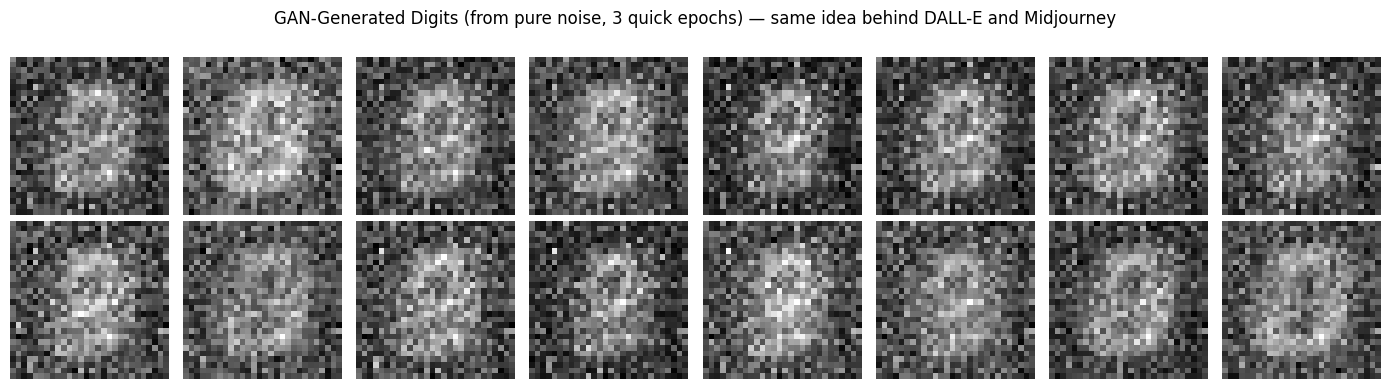

In [1]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
# Classroom-sized subset: 12,800 images train a rough-but-recognizable GAN in ~2-3 minutes on CPU
subset    = torch.utils.data.Subset(dataset, range(12_800))
loader    = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

# ── Generator: noise → image ───────────────────────────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: image → real/fake ─────────────────────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
bce   = nn.BCELoss()

d_losses, g_losses = [], []
EPOCHS = 3  # enough to see digits emerge from noise; raise for sharper samples
for epoch in range(EPOCHS):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── Train Discriminator ─────────────────────────────────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs,1)) + bce(D(fake), torch.zeros(bs,1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── Train Generator ─────────────────────────────────────────────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs,1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    print(f"Epoch {epoch+1}/{EPOCHS} — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Show generated images ──────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray'); ax.axis('off')
plt.suptitle("GAN-Generated Digits (from pure noise, 3 quick epochs) — same idea behind DALL-E and Midjourney")
plt.tight_layout(); plt.show()

---

## ✅ Summary | الملخص

Great job completing this example!

**What you learned:**
- Core concepts demonstrated in the code
- Practical implementation details

**Next steps:**
- Complete the exercises in `exercises/` folder
- Review the quiz materials
- Proceed to the next example

---

**💡 Tip:** If you see errors, make sure:
- All libraries are installed: `pip install -r requirements.txt`
- You're using Python 3.8+
- Cells are executed in order


## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434)
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)

**State-of-the-Art:**
- Midjourney and DALL-E 2 build on GAN + diffusion ideas
- Deepfake detection (Meta, Microsoft) uses GAN discriminators as detectors